Lab Assignment 2 Text Analytics
Sean Christopher (IS01083522)
Muhammad Anas bin Shamsul SW0106060

In [6]:
import sys
!{sys.executable} -m pip install pandas nltk scikit-learn matplotlib vaderSentiment

  Using cached nltk-3.9.4-py3-none-any.whl.metadata (3.2 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
  Using cached click-8.3.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached regex-2026.4.4-cp311-cp311-win_amd64.whl.metadata (41 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
     ---------------------------------------- 0.0/41.7 kB ? eta -:--:--
     ---------------------------------------- 41.7/41.7 kB 2.0 MB/s eta 0:00:00
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
   --------------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import re
import nltk
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sean\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Sean\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Sean\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
# Load the data
df = pd.read_csv(r'C:\Users\Sean\Desktop\Reviews.csv')

# Sample 10,000 rows to keep it fast (you can increase this later)
df = df.sample(10000, random_state=42).reset_index(drop=True)

print(f"Dataset loaded with {df.shape[0]} rows.")
df.head()

Dataset loaded with 10000 rows.


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,165257,B000EVG8J2,A1L01D2BD3RKVO,"B. Miller ""pet person""",0,0,5,1268179200,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...
1,231466,B0000BXJIS,A3U62RE5XZDP0G,Marty,0,0,5,1298937600,great kitty treats,My cat loves these treats. If ever I can't fin...
2,427828,B008FHUFAU,AOXC0JQQZGGB6,Kenneth Shevlin,0,2,3,1224028800,COFFEE TASTE,A little less than I expected. It tends to ha...
3,433955,B006BXV14E,A3PWPNZVMNX3PA,rareoopdvds,0,1,2,1335312000,So the Mini-Wheats were too big?,"First there was Frosted Mini-Wheats, in origin..."
4,70261,B007I7Z3Z0,A1XNZ7PCE45KK7,Og8ys1,0,2,5,1334707200,Great Taste . . .,and I want to congratulate the graphic artist ...


In [3]:
# 1. Define Sentiment Mapping
def set_sentiment(score):
    if score <= 2: return "Negative"
    if score == 3: return "Neutral"
    return "Positive"

df['Sentiment'] = df['Score'].apply(set_sentiment)

# 2. Text Cleaning Function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text) # Remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation/numbers
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['CleanedText'] = df['Text'].apply(clean_text)
print("Preprocessing complete.")

Preprocessing complete.


In [4]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['CleanedText'])
y = df['Sentiment']

# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
print("Machine Learning (Logistic Regression) Results:")
print(classification_report(y_test, lr_preds))

Machine Learning (Logistic Regression) Results:
              precision    recall  f1-score   support

    Negative       0.76      0.32      0.45       298
     Neutral       0.23      0.02      0.04       152
    Positive       0.82      0.99      0.90      1550

    accuracy                           0.81      2000
   macro avg       0.60      0.44      0.46      2000
weighted avg       0.77      0.81      0.76      2000



In [6]:
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05: return "Positive"
    elif score <= -0.05: return "Negative"
    else: return "Neutral"

# Apply VADER to the same test set for comparison
# We get the original text for the rows that were in our test set
test_indices = y_test.index
vader_preds = df.loc[test_indices, 'Text'].apply(get_vader_sentiment)

print("Lexicon-Based (VADER) Results:")
print(classification_report(y_test, vader_preds))

Lexicon-Based (VADER) Results:
              precision    recall  f1-score   support

    Negative       0.58      0.38      0.46       298
     Neutral       0.12      0.04      0.06       152
    Positive       0.84      0.95      0.90      1550

    accuracy                           0.80      2000
   macro avg       0.52      0.46      0.47      2000
weighted avg       0.75      0.80      0.77      2000



--- Model Performance Comparison ---
                      Model  Accuracy
0  Logistic Regression (ML)     0.813
1           VADER (Lexicon)     0.800


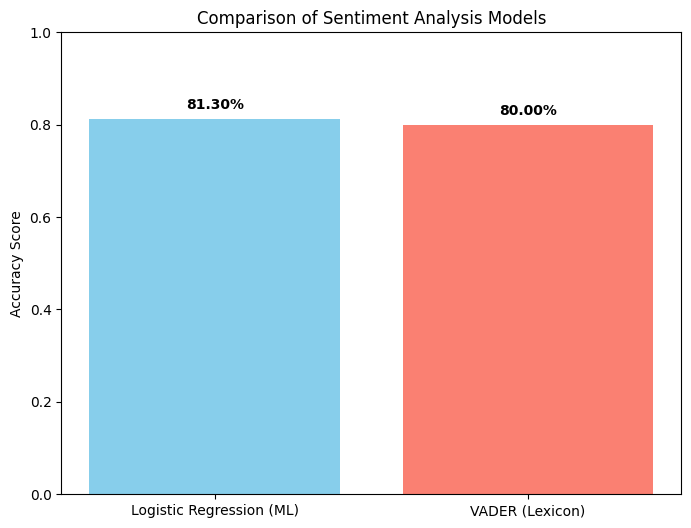

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# 1. Calculate Accuracy for only the two models you have run
lr_acc = accuracy_score(y_test, lr_preds)
vader_acc = accuracy_score(y_test, vader_preds)

# 2. Create a Summary DataFrame (removed Naive Bayes)
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression (ML)', 'VADER (Lexicon)'],
    'Accuracy': [lr_acc, vader_acc]
})

print("--- Model Performance Comparison ---")
print(comparison_df)

# 3. Create the Bar Chart
plt.figure(figsize=(8, 6))
plt.bar(comparison_df['Model'], comparison_df['Accuracy'], color=['skyblue', 'salmon'])
plt.ylabel('Accuracy Score')
plt.title('Comparison of Sentiment Analysis Models')
plt.ylim(0, 1.0)
for i, val in enumerate(comparison_df['Accuracy']):
    plt.text(i, val + 0.02, f'{val:.2%}', ha='center', fontweight='bold')
plt.show()

Strengths and Weaknesses Analysis:
Logistic Regression (ML):
Strength: It is very accurate because it learns the specific language of food reviews (e.g., "delicious" = positive, "stale" = negative).
Weakness: It requires a lot of labeled data and cannot handle words it hasn't seen before in training.
VADER (Lexicon):
Strength: It is "ready to use" out of the box and understands social media language like emojis, exclamation points, and "ALL CAPS."
Weakness: It is less accurate for specific domains. It might not realize "The coffee was a bit thin" is a negative review because "thin" isn't always a negative word in its general dictionary.
